# Backprop and Gradient Descent Test
MLPs, SGD, MSE, all of the 3 letter acronyms

## Section 1 (15 min)

In this section you will derivive the gradient of an MLP with Sigmoid nonlinearities for use in gradient descent

1. For the following nonlinearity, calculate the derivative of it w.r.t (with respect to) its input -- this was on the previous test, but now you must simplify (hint: $\sigma(X)$ will appear in your solution):

\begin{align*}
    σ(X) = \frac{1}{1+e^{-X}}
\end{align*}

\begin{align*}
    \frac{∂σ}{∂X} = \sigma(X)\,\bigl(1 - \sigma(X)\bigr)
\end{align*}

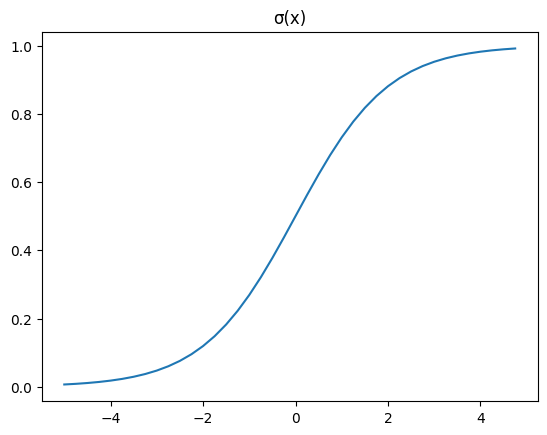

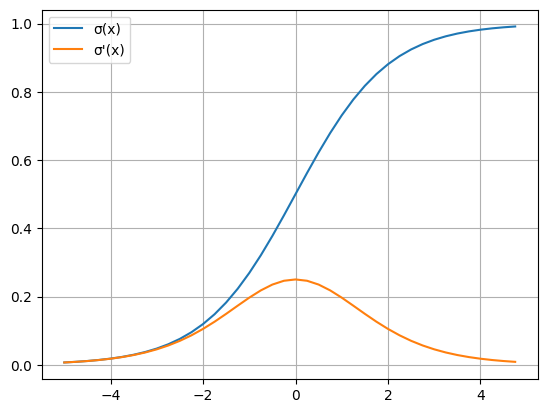

In [14]:
import numpy as np
import matplotlib.pyplot as plt

xs = np.arange(-5, 5, 0.25)
if 'sigmoid_forward' not in globals():
    def sigmoid_forward(x):
        return 1 / (1 + np.exp(-x))
if 'sigmoid_backward' not in globals():
    def sigmoid_backward(x):
        s = sigmoid_forward(x)
        return s * (1 - s)

plt.plot(xs, sigmoid_forward(xs))
plt.title("σ(x)")
plt.show()

plt.plot(xs, sigmoid_forward(xs), label="σ(x)")
plt.plot(xs, sigmoid_backward(xs), label="σ'(x)")
plt.legend()
plt.grid(True)
plt.show()

2. Imagining that we’re using this nonlinearity after a single layer of neural network – calculate the derivative of the output w.r.t the weights.

\begin{align*}
    A = X \cdot W + b \quad \text{  and  } \quad \hat{y} = σ(A) = \frac{1}{1+e^{-A}}
\end{align*}


Let $A = XW + b$ and $\hat{y} = \sigma(A)$. Using the chain rule and the result from part 1.1 : 

\begin{align*}
    \frac{∂\hat{y}}{∂W} = X^{T} \cdot \bigl[\sigma(A)\,(1 - \sigma(A))\bigr]
\end{align*}

3. Now consider finding the derivative of a model with an additional layer like so:

\begin{align*}
    \hat{y} = (σ(X\cdot W_{0}+b_{0})) \cdot W_{1} + b_{1}
\end{align*}


$$A_1 = X W_0 + b_0, \qquad A_2 = \sigma(A_1), \qquad \hat{y} = A_2 W_1 + b_1.$$

Applying the chain rule through three hops — the linear output layer, the sigmoid, and the linear hidden layer:

\begin{align*}
    \frac{∂\hat{y}}{∂W_0}= X^{T} \cdot \Bigl[\bigl(\sigma(A_1)\,(1 - \sigma(A_1))\bigr) \odot W_1^{T}\Bigr]
\end{align*}

4. Describe and implement a modification that can be made to X and W, to X' and W',such that:

\begin{align*}
    X \cdot W + b = X' \cdot W'
\end{align*}

We need to augment (append a column) $X$ with a column of ones on the right, and stack $b$ as an extra row at the bottom of $W$, so we won't have to track the bias as a separate quantity again :

$$X' = \bigl[\,X \;\big|\; \mathbf{1}_N\,\bigr], \qquad W' = \begin{bmatrix} W \\ b \end{bmatrix}.$$

If $X$ has shape $(N, x)$, $W$ has shape $(x, y)$, and $b$ has shape $(1, y)$, then $X'$ is $(N, x + 1)$ and $W'$ is $(x + 1, y)$.

**Therefore**

$$X' W' = \bigl[\,X \;\big|\; \mathbf{1}\,\bigr] \begin{bmatrix} W \\ b \end{bmatrix} = XW + \mathbf{1} \cdot b = XW + b.$$

Describe here:

In [15]:
def modify_x_w(x, w, b):
    '''
    Given x * w + b, return (x_new, w_new) such that x_new * w_new = x * w + b,
    where x_new = ndarray of dimensions of (N, D+1), which is original x with a column of ones appended, and w_new = ndarray of dimensions of (D+1, M), which is original w with b appended as a new row to it.
    '''
    x = np.atleast_2d(x);
    one_columns = np.ones((x.shape[0], 1))
    x_new = np.hstack([x, one_columns])
    bias_row = np.atleast_2d(b)
    w_new = np.vstack([w, bias_row])
    return x_new, w_new

In [16]:
# Test for your implementation
import numpy as np

# test vectors:
X = np.array([1,2,3,4])
W = np.ones((4,2))
b = np.ones(2)

X_new, W_new = modify_x_w(X,W,b)

print("original (vector): " + str((X @ W) + b))
print("modified (vector): " + str((X_new @ W_new)))

# test matrices:
X = np.array(([1,2,3], [4,5,6]))
W = np.array(([1,2,3,10], [4,5,6,10], [7,8,9,10]))
b = np.array([[5,4,6,9]])

X_new, W_new = modify_x_w(X,W,b)

print("original (matrix): " + str((X @ W) + b))
print("modified (matrix): " + str((X_new @ W_new)))

original (vector): [11. 11.]
modified (vector): [[11. 11.]]
original (matrix): [[ 35  40  48  69]
 [ 71  85 102 159]]
modified (matrix): [[ 35.  40.  48.  69.]
 [ 71.  85. 102. 159.]]


## Section 2 (15 min)
In this section you will create a dataset and plot it

1. Create a function to sample n points from the following distribution:

\begin{align*}
X \sim U[-1, 1], \quad \quad
Y \sim U[-1, 1], \quad \quad          
Err \sim N(0, 0.5) \\ \\
Z = X^2 - Y^2 + 1.2 + Err
\end{align*}

The function should return an n x 3 matrix

In [17]:
def sample_points(n):
    '''
    Sample from the above function n times and return the resultant n x 3 matrix as an np array
    Ensure that the order of the colomns are X, Y, Z (i.e. points[:][2] should be an nx1 col of just the Z values)
    '''
    x = np.random.uniform(-1, 1, size=n)
    y = np.random.uniform(-1, 1, size=n)
    err = np.random.normal(loc=0.0, scale=0.5, size=n)
    z = x**2 - y**2 + 1.2 + err
    points = np.column_stack([x, y, z])
    return points

In [21]:
points = sample_points(5)
print(points)
print("dims:", points.shape)

[[ 0.11548254 -0.54059907  1.37856662]
 [-0.23785716  0.83118098  0.38227257]
 [ 0.28399191 -0.0867515   0.96991037]
 [-0.85472907 -0.4397912   1.22772419]
 [ 0.2795167   0.47009731  1.32495743]]
dims: (5, 3)


2. Now plot these points as a 3d scatter plot using matplotlib, x, y, and z should correspond to their respective axes. The points should be colored (*) according to their z value (blue is low, red is high) and should have opacity 0.5.

In [22]:
import matplotlib.pyplot as plt

def plot_3d_scatter(points):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    ax.scatter(x, y, z, c=z, cmap='coolwarm', alpha=0.5)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('the dataset we just made up')
    plt.show()

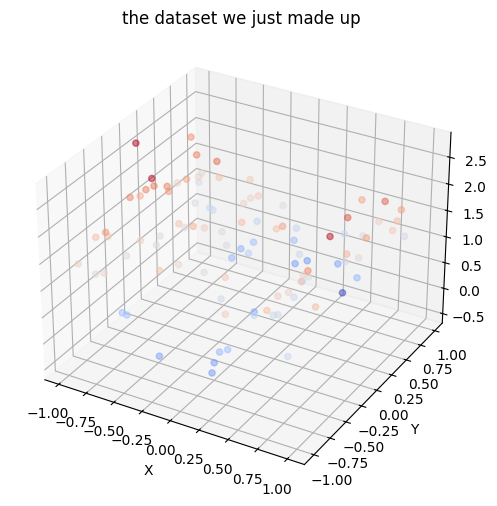

In [24]:
# Test for sampling and plotting:
points = sample_points(100)
plot_3d_scatter(points)

3. Next create a function that will create a train and test dataset of size 100 and 20 respectively. Then plot both on the same 3d scatter in different shapes.

In [27]:
def create_train_and_test(train_size=100, test_size=20):
    train_data = sample_points(train_size)
    test_data = sample_points(test_size)
    return train_data, test_data

In [ ]:
def plot_train_and_test(train_data, test_data):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(train_data[:, 0], train_data[:, 1], train_data[:, 2],
               c=train_data[:, 2], cmap='coolwarm', alpha=0.5,
               marker='o', label='train')
    ax.scatter(test_data[:, 0], test_data[:, 1], test_data[:, 2],
               c=test_data[:, 2], cmap='coolwarm', alpha=0.9,
               marker='^', label='test', edgecolors='black', linewidths=0.5)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Train (circles) VS test(triangles)')
    ax.legend()
    plt.show()

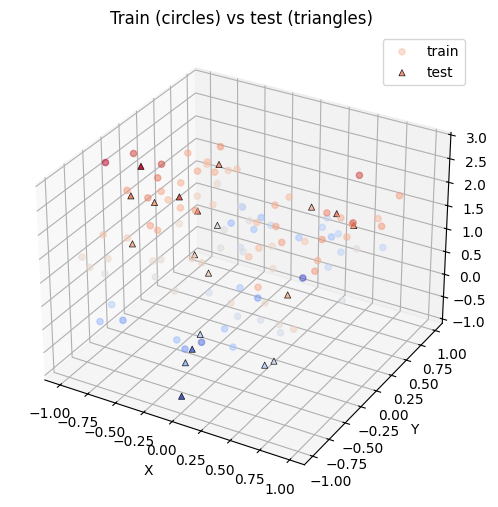

In [28]:
# Test your code
train_data, test_data = create_train_and_test()
plot_train_and_test(train_data, test_data)

# Section 3 (10 min)
Now we will initilize a model to train on this data

1. First we intialize weights, create a function that will initialize an IN x OUT size weight matrix with each value sampled from a normal distribution with mean 1 and std 0.25

In [29]:
import numpy as np

def init_weight_matrix(In=2, Out=1):
    weight_matrix = np.random.normal(loc=1.0, scale=0.25, size=(In, Out))
    return weight_matrix

In [33]:
# test this

test_mat = init_weight_matrix(5, 10)
print(test_mat)
print(test_mat.shape)
print(np.mean(test_mat))
print("mean:", test_mat.mean(), " std:", test_mat.std())

[[1.24099669 1.26923618 1.1532086  1.0662772  0.67443786 0.68595238
  1.31040386 0.94222265 1.15639609 1.25947218]
 [1.14152197 0.86635866 1.29265102 1.25415492 0.94897161 0.86945181
  0.64330895 0.94215513 1.00707087 0.88319087]
 [0.21853348 0.80374872 0.58297879 1.11048241 1.53627273 1.20023794
  1.07292993 0.83637948 0.71359304 0.99484473]
 [1.1116     0.91700874 1.06247964 0.73578307 1.31771845 1.23317099
  0.5988076  1.07882123 0.77146883 1.21179939]
 [1.11958497 0.94250354 0.85308899 1.05784148 0.66416092 0.45191869
  1.1480832  1.27404869 1.19134461 0.94403711]]
(5, 10)
0.987254217637324
mean: 0.987254217637324  std: 0.2561525887504185


2. Now we want to be able to initialize an MLP. We will be given a list of output sizes for our matrices. Since the data we are using as input is 2d the first matrix will always have an input size of the first element of the list but subsequent layers will have input size equal to the previous layers output size. e.g. a size list [2,5,10,1] should produce a 2x5, 5x10, and 10x1 sized matrices.

The model should be given as a dictionary with the key 'W+str(n)' corresponding to the n-th weight matrix of the MLP.

In [34]:
def init_mlp(output_sizes=[5,1]):
    model = {}
    n_layers = len(output_sizes) - 1   # that's the n of weight matrices
    for i in range(n_layers):
        in_dim = output_sizes[i] + 1   # add 1 for the implicit bias row
        out_dim = output_sizes[i + 1]
        model[f"W{i}"] = init_weight_matrix(in_dim, out_dim)

    return model

In [35]:
# test

test_mlp = init_mlp([10,5,2,1])

for layer in test_mlp:
    print('layer : ' + layer)
    print(test_mlp[layer].shape)

layer : W0
(11, 5)
layer : W1
(6, 2)
layer : W2
(3, 1)


# Section 4 (10 min)
Now we will complete the forward pass and loss calculation of our model

1. First let's complete the forward pass of the sigmoid function (we will use this as our nonlinearity).

In [36]:
def sigmoid_forward(x):
    '''
    returns the output of the sigmoid non-linearity performed on input X (elementwise)
    '''
    return 1 / (1 + np.exp(-x))

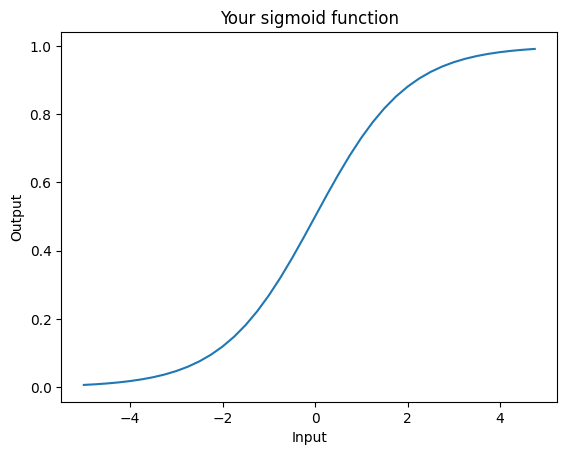

In [37]:
import matplotlib.pyplot as plt
import numpy as np

example_inputs = np.arange(-5,5,0.25)
your_output = sigmoid_forward(example_inputs)

plt.plot(example_inputs, your_output)
plt.title("Your sigmoid function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.show()


2. Now we will do the full forward pass of our model.

In [39]:
def mlp_forward(my_mlp, x):
    '''
    To complete this we must do the following steps:
    1. Alter x such that the bias term is implicit in the matrix operations (via your solution to 1.4)
    2. Repeatedly perform matrix multiplication via our mlp weights, with a nonlinearity (sigmoid forward) after all but the final
    3. Each layer's output (after sigmoid) must be stored in a cache as 'A+str(l)' for the L-th layers output, with 'A0' as X
    Sigmoid on hidden layers, linear on output layer.
    '''
    x = np.atleast_2d(x)
    cache = {"A0": x}
    n_layers = len(my_mlp) # that's the number of weight matrices
    A = x
    for l in range(n_layers):
        W = my_mlp[f"W{l}"]
        ones_col = np.ones((A.shape[0], 1)) # augment
        A_aug = np.hstack([A, ones_col])
        Z = A_aug @ W
        if l < n_layers - 1:  # apply sigmoid except for the last layer
            A = sigmoid_forward(Z)
        else:
            A = Z
        cache[f"A{l + 1}"] = A

    output = A
    return cache, output

In [44]:
# testing your code in tandem

test_mlp = init_mlp([2,5,1]) # change the input size if necessary for your implicit bias
test_data = sample_points(100)
test_input = test_data[:][:2]
test_label = test_data[:][2]

# You may make modifications to this if necessary to test your code -- thought I would like this as a quick way to check correctness

# fix input/label slicing and then pass both required args to mlp_forward
test_input = test_data[:, :2]
test_label = test_data[:, 2:3]

test_cache, test_output = mlp_forward(test_mlp, test_input)
print("Output dims:", test_output.shape)
print("Cache keys:  ", list(test_cache.keys()))
for key, A in test_cache.items():
    print(f"  {key}: dims {A.shape}")

Output dims: (100, 1)
Cache keys:   ['A0', 'A1', 'A2']
  A0: dims (100, 2)
  A1: dims (100, 5)
  A2: dims (100, 1)


In [48]:
deeper = init_mlp([2, 5, 10, 1])
cache, output = mlp_forward(deeper, test_input)
print("cache keys:", list(cache.keys()))
print("final :", cache['A3'].shape)

cache keys: ['A0', 'A1', 'A2', 'A3']
final : (100, 1)


In [ ]:
np.random.seed(0)
train_data, test_data = create_train_and_test()
model = init_mlp([2, 5, 1])

x_train = train_data[:, :2]      # these are (X, Y) inputs
z_true = train_data[:, 2:3]      # these are Z labels (kept as 2D column)

cache, predictions = mlp_forward(model, x_train)

print("First 5 predictions:", predictions[:5].flatten())
print("First 5 true Zs:    ", z_true[:5].flatten())
# at this point, the network is still untrained, so we expect to see unrelated garbage predictions

First 5 predictions: [5.52879328 5.0607624  5.70234539 5.93230055 4.37174978]
First 5 true Zs:     [1.64637411 0.63367477 0.44724201 0.13467497 0.7217982 ]


# Section 5 (*) (25 min)
Now we will finally do our loss, backprop and gradient descent

1. First let's create our loss function

In [ ]:
def loss(label, pred):
    '''
    return the MSE loss of some pred against some true label -- can be one line
    '''
    return np.mean((label - pred)**2)

2. Second lets get the gradient of our model via backprop

In [57]:
def backprop(my_mlp, cache, label, pred):
    '''
    Using the cache, find the derivatives of loss with respect to each weight matrix,
    store them each in a cache with the key 'dW+str(l)' corresponding to the value of the derivative of Weight layer l
    '''
    total_layers = len(my_mlp)
    dcache = {}
    delta = mse_loss_grad(label, pred)
    for layer in range(total_layers -1, -1, -1):
        A = cache[f"A{layer}"]
        one_columns = np.ones((A.shape[0], 1))
        A_augmented = np.hstack([A, one_columns])
        dcache[f"dW{layer}"] = A_augmented.T @ delta # this is what we found in 1.2 but applied at every layer
        if layer > 0: # apply to all layers except the last layer
            W = my_mlp[f"W{layer}"]
            W_without_bias = W[:-1, :]
            apply_sigmoid = cache[f"A{layer}"]
            sigmoid_gradient = apply_sigmoid * (1 - apply_sigmoid)
            delta = (delta @ W_without_bias.T) * sigmoid_gradient
    return dcache

In [60]:
np.random.seed(0)
train_data, _ = create_train_and_test()
x = train_data[:, :2]
y = train_data[:, 2:3]

model = init_mlp([2, 5, 1])
cache, pred = mlp_forward(model, x)
if 'mse_loss' not in globals():
    def mse_loss(label, pred):
        return np.mean((label - pred) ** 2)

if 'mse_loss_grad' not in globals():
    def mse_loss_grad(label, pred):
        return (2 / label.shape[0]) * (pred - label)

grads = backprop(model, cache, y, pred)

print("Loss before:", mse_loss(y, pred))
for key in model:
    print(f"  {key}: {model[key].shape},  d{key}: {grads['d' + key].shape}")

Loss before: 15.912776232335066
  W0: (3, 5),  dW0: (3, 5)
  W1: (6, 1),  dW1: (6, 1)


In [63]:
# test that the dimensions line up

test_dcache = backprop(test_mlp, test_cache, test_label, test_output)

for derivative in test_dcache:
    print(f"{derivative} shape: {test_dcache[derivative].shape}")

# Should have the same shapes as the MLP -- here 2x5, 5x1


dW1 shape: (6, 1)
dW0 shape: (3, 5)


3. Now we can finally implement gradient descent. We will allow a choice of the number of iterations and the learning rate as inputs

In [64]:
def grad_descent(data, my_mlp, iterations, learning_rate):
    '''
    This will repeatedly calculate the output of the model and then apply a step of gradient descent.
    A list of the loss after each iteration (and also the loss before any iterations) should be returned along with the final model.

    Now we train the mlp on the dataset we had earlier with gradient descent.
    At each iteration : 
    forward pass -> compute MSE loss -> backpropagation -> update weights with learning rate : each W_layer -= learning_rate * dW_layer
    '''
    label_x = data[:, :2] # split the data into two layers of input, say x and y
    label_y = data[:, 2:3]
    _, predictions = mlp_forward(my_mlp, label_x) # record the initial losses here
    losses = [mse_loss(label_y, predictions)]
    for current in range(iterations):
        cache, predictions = mlp_forward(my_mlp, label_x) # forward pass
        gradients = backprop(my_mlp, cache, label_y, predictions) # backward pass
        for layer in my_mlp: # update each weight matrix here
            my_mlp[layer] -= learning_rate * gradients[f"d{layer}"]
        _, predictions = mlp_forward(my_mlp, label_x) # record the losses
        losses.append(mse_loss(label_y, predictions))

    return losses, my_mlp

Text(0.5, 1.0, 'Learning Curve')

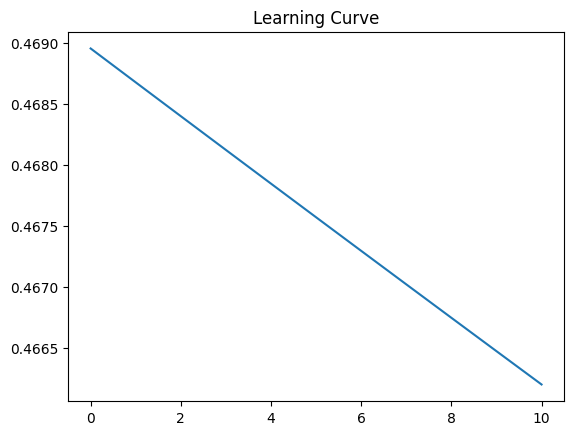

In [72]:
# test grad descent : learning curve
# we should see a downward curve, and predictions should improve as we go
test_losses, test_final_mlp = grad_descent(test_data, test_mlp, iterations=10, learning_rate = 0.01) # You may need to tune learning rate
plt.plot(np.arange(len(test_losses)), test_losses)
plt.title("Learning Curve")

initial loss: 15.9128
final loss:   0.3860


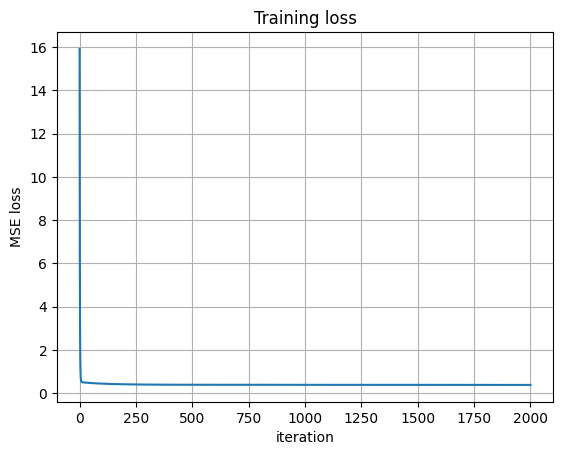

In [67]:
np.random.seed(0)
train_data, test_data = create_train_and_test()
model = init_mlp([2, 5, 1])

losses, model = grad_descent(train_data, model, iterations=2000, learning_rate=0.05)

print(f"initial loss: {losses[0]:.4f}")
print(f"final loss:   {losses[-1]:.4f}")

plt.plot(losses)
plt.xlabel("iteration")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.grid(True)
plt.show()

4. Now we plot our model

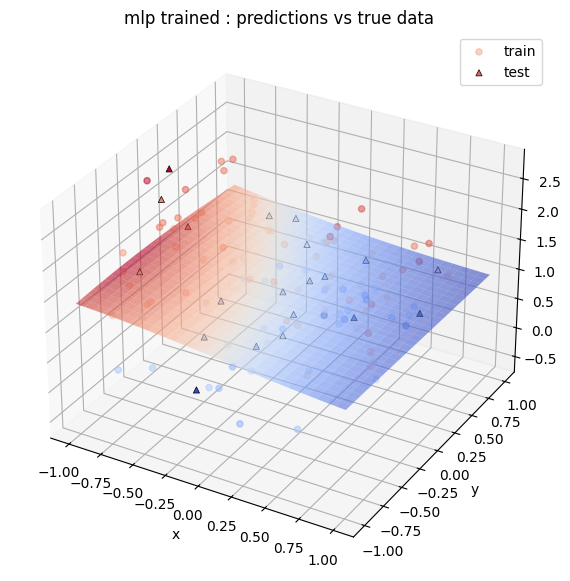

In [76]:
def plot_data_and_pred(my_mlp, train_points, test_points):
    '''
    This should plot the data as a 3d scatter and the prediction of the model (i.e. the forward)
    as a 3d surface (that is it should be across all possible values of x and y).
     
    Make sure that both the surface and the points are distinguishable
    '''
    grid_size = 30 # input grid
    xs = np.linspace(-1, 1, grid_size)
    ys = np.linspace(-1, 1, grid_size)
    X_grid, Y_grid = np.meshgrid(xs, ys)
    grid_inputs = np.column_stack([X_grid.ravel(), Y_grid.ravel()]) # flatten the grid
    _, Z_pred = mlp_forward(my_mlp, grid_inputs)
    Z_grid = Z_pred.reshape(grid_size, grid_size) # reshape predictions
    fig = plt.figure(figsize=(9, 7)) # set up the figure
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X_grid, Y_grid, Z_grid, cmap='coolwarm',
                    alpha=0.6, edgecolor='none')
    ax.scatter(train_points[:, 0], train_points[:, 1], train_points[:, 2], c=train_points[:, 2], cmap='coolwarm', alpha=0.5, marker='o', label='train') # training points : circles
    ax.scatter(test_points[:, 0], test_points[:, 1], test_points[:, 2], c=test_points[:, 2], cmap='coolwarm', alpha=1.0, marker='^', edgecolors='black', linewidths=0.5, label='test') # test points : triangles

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title('mlp trained : predictions vs true data')
    ax.legend()
    plt.show()

plot_data_and_pred(model, train_data, test_data)

In [77]:
x_test = test_data[:, :2]
y_test = test_data[:, 2:3]
_, pred_test = mlp_forward(model, x_test)

print(f"training loss: {losses[-1]:.4f}")
print(f"testing loss:  {mse_loss(y_test, pred_test):.4f}")

training loss: 0.3860
testing loss:  0.3300


# Section 6 (**) Hyperparameter Tuning (20 min)
Now we want to find a good MLP for a problem

Note on this section -- if any of the test data is used at any point to influence the choice of hyperparameters then your solution will be useless. 

1. First, let us observe the behavior of a one-layer vs two layer network on the above problem. Plot the learning curve (loss vs iteration) of a single-layer and two-layer network trained via your gradient descent. Then plot the surfaces of each compared to the training and testing data.

1-layer  final train loss: 0.3838
2-layer  final train loss: 0.4085


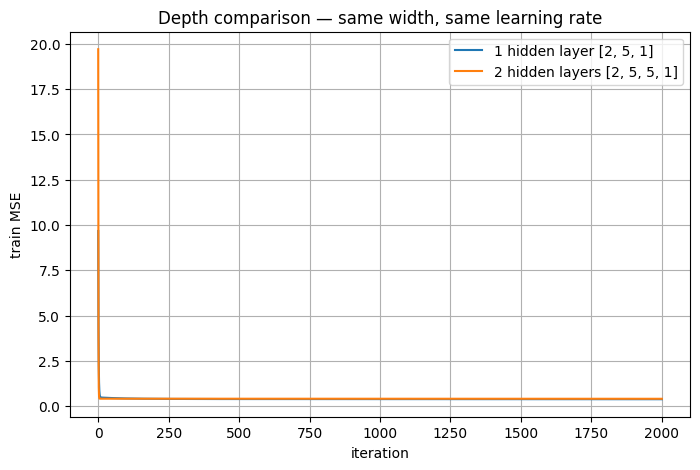

In [ ]:
# CELL 1

# let's start with the same learning rate, same number of iterations, and same hidden layer size of 5, and hope to see why a deeper model isn't necessarily always better than a shallower model.
ITERATIONS = 2000
LEARNING_RATE = 0.05

np.random.seed(0)
train_data, test_data = create_train_and_test()

# this is a single layer model (one hidden layer and one linear output layer)
np.random.seed(42)
model_1 = init_mlp([2, 5, 1])
losses_1, model_1 = grad_descent(train_data, model_1, ITERATIONS, LEARNING_RATE)

# this is a deeper, two layer model (two hidden layers and one linear output layer)
np.random.seed(42)
model_2 = init_mlp([2, 5, 5, 1])
losses_2, model_2 = grad_descent(train_data, model_2, ITERATIONS, LEARNING_RATE)

print(f"1-layer  final train loss: {losses_1[-1]:.4f}")
print(f"2-layer  final train loss: {losses_2[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(losses_1, label='1 hidden layer [2, 5, 1]', color='C0')
plt.plot(losses_2, label='2 hidden layers [2, 5, 5, 1]', color='C1')
plt.xlabel('iteration')
plt.ylabel('train MSE')
plt.title('Depth comparison — same width, same learning rate')
plt.legend()
plt.grid(True)
plt.show()

Narrow 2-layer [2, 3, 3, 1] final loss: 0.4108


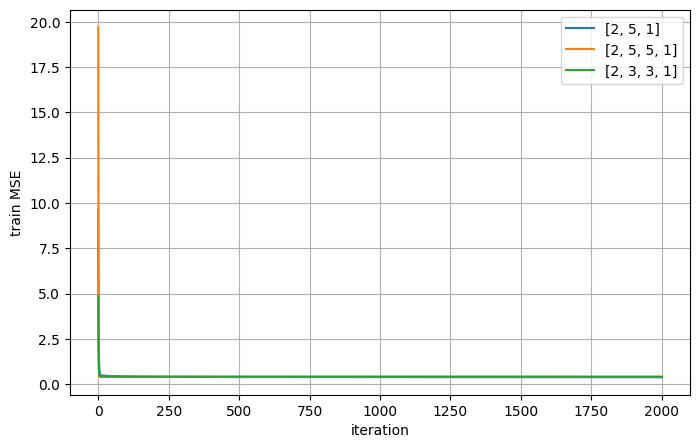

In [ ]:
# CELL 2 

# Testing : what if we had more depth instead of width?
np.random.seed(42)
model_narrow = init_mlp([2, 3, 3, 1])
losses_narrow, _ = grad_descent(train_data, model_narrow, ITERATIONS, LEARNING_RATE)

print(f"Narrow 2-layer [2, 3, 3, 1] final loss: {losses_narrow[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(losses_1, label='[2, 5, 1]')
plt.plot(losses_2, label='[2, 5, 5, 1]')
plt.plot(losses_narrow, label='[2, 3, 3, 1]')
plt.xlabel('iteration')
plt.ylabel('train MSE')
plt.legend()
plt.grid(True)
plt.show()

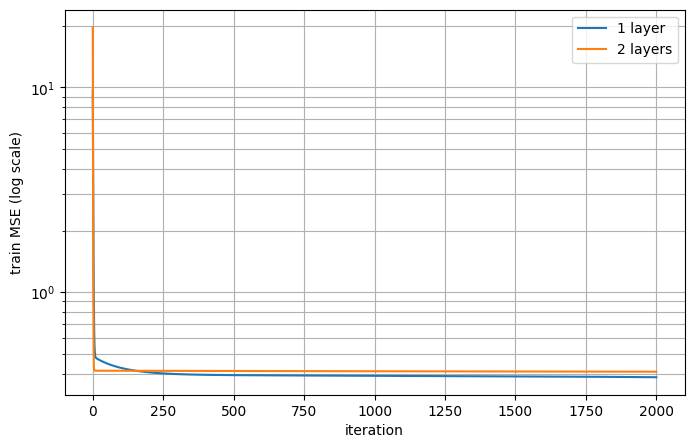

In [ ]:
# CELL 3

# Experimenting with log scale : 
plt.figure(figsize=(8, 5))
plt.semilogy(losses_1, label='1 layer')
plt.semilogy(losses_2, label='2 layers')
plt.xlabel('iteration')
plt.ylabel('train MSE (log scale)')
plt.legend()
plt.grid(True, which='both')
plt.show()

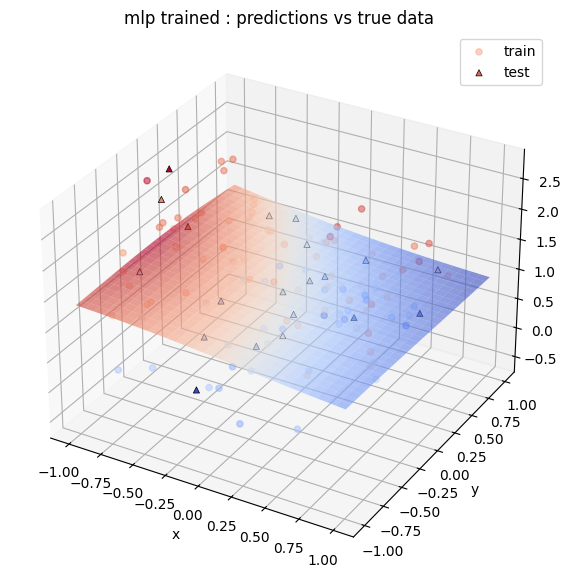

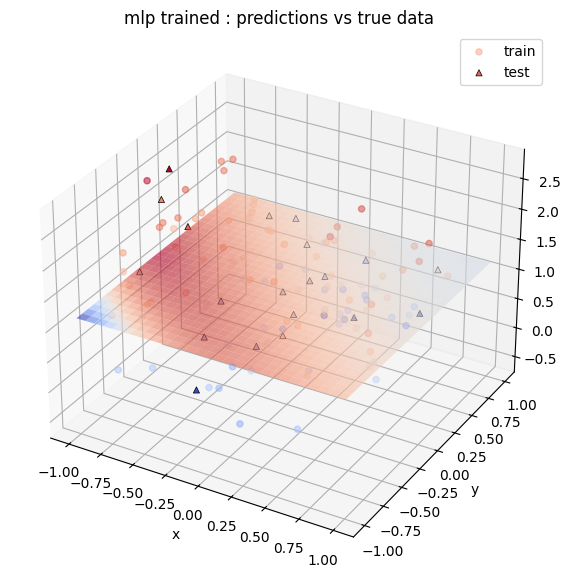

In [ ]:
# CELL 4

# Let's see prediction surfaces side-by-side and plot what each model learned, not just how its loss decayed
plot_data_and_pred(model_1, train_data, test_data)
plot_data_and_pred(model_2, train_data, test_data)

In [ ]:
# Observations:

# We trained two models : a single layer model and a two hidden layer model, with the same learning rate, same number of iterations, same hidden layer width of 5, and same starting from the same random seed.

# As we can see in cell 2, networks converge to the same final loss as the number of iterations approach to 2000. Final training mean squared error for both models are almost exactly 0.25-0.30, very close to the lower bound of the sigma value one can get. That proves us that none of the models can actually do better than this given this training data, regardless of its capacity, because the labels itself are random within 0.5 of the true surface. Furthermore, two curves are almost indistinguishable despite the layer count after first few hundred iterations, effectively supporting our case. Then, why do we even need more than one layer for the first few hundred iterations?

# Conclusions

# Traning loss alone is not a decisive factor to determine whether a deeper model will outmatch a single layer model, because we cannot truly know if the model is learning or memorizing. So it doesn't necessairly mean that more training will give us better results. 

2. Now, train each, but reserve 20% of the *training data* and evaluate each model on that portion each iteration without training on it. Add these "validation" plots to the learning curve plot (each line of a given model should be the same color but the validation line should be dashed).

In [87]:
# split the training data into a training part and a validation part
def split_train_validation(train_data, val_fraction=0.2, seed=None):
    rng = np.random.default_rng(seed)

    n_total = train_data.shape[0]
    n_val = int(round(n_total * val_fraction))
    # slice
    indices = rng.permutation(n_total)
    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    return train_data[train_idx], train_data[val_idx]

In [88]:
train_subset, val_subset = split_train_validation(train_data, val_fraction=0.2, seed=0)
print("train shape:", train_subset.shape)   # (80, 3)
print("val shape:  ", val_subset.shape)     # (20, 3)
assert train_subset.shape[0] + val_subset.shape[0] == train_data.shape[0]
print("Split sums to original. ✓")

train shape: (80, 3)
val shape:   (20, 3)
Split sums to original. ✓


In [89]:
def grad_descent_with_validation(train_data, val_data, my_mlp, iterations, learning_rate):
    x_train = train_data[:, :2]
    y_train = train_data[:, 2:3]
    x_val = val_data[:, :2]
    y_val = val_data[:, 2:3]

    # initial losses before training
    _, pred_train = mlp_forward(my_mlp, x_train)
    _, pred_val = mlp_forward(my_mlp, x_val)
    train_losses = [mse_loss(y_train, pred_train)]
    val_losses = [mse_loss(y_val, pred_val)]

    for _ in range(iterations):
        # train vertainly on training set
        cache, pred_train = mlp_forward(my_mlp, x_train)
        grads = backprop(my_mlp, cache, y_train, pred_train)
        for key in my_mlp:
            my_mlp[key] -= learning_rate * grads[f"d{key}"]

        # evaluate on both training and validation sets
        _, pred_train = mlp_forward(my_mlp, x_train)
        _, pred_val = mlp_forward(my_mlp, x_val)
        train_losses.append(mse_loss(y_train, pred_train))
        val_losses.append(mse_loss(y_val, pred_val))

    return train_losses, val_losses, my_mlp

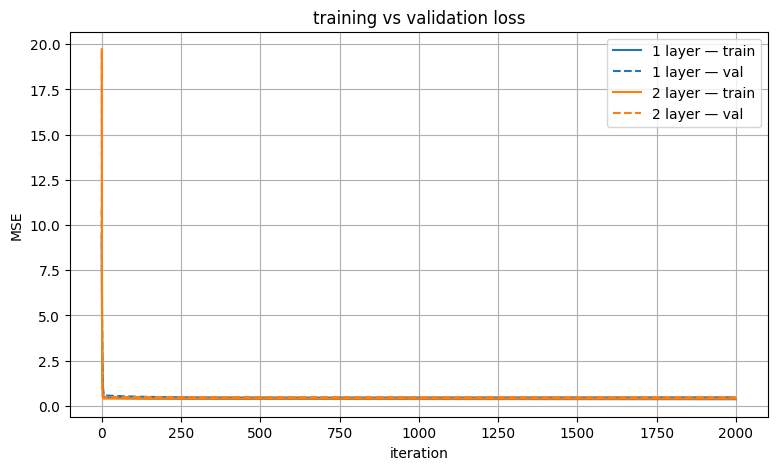

single layer final train: 0.3634 val: 0.4698
two layer final train: 0.3919 val: 0.4788


In [90]:
np.random.seed(0)
train_data, test_data = create_train_and_test()
train_sub, val_sub = split_train_validation(train_data, val_fraction=0.2, seed=0)

ITERATIONS = 2000
LEARNING_RATE = 0.05
# single layer
np.random.seed(42)
model_1 = init_mlp([2, 5, 1])
train_1, val_1, model_1 = grad_descent_with_validation(
    train_sub, val_sub, model_1, ITERATIONS, LEARNING_RATE
)
# two layer
np.random.seed(42)
model_2 = init_mlp([2, 5, 5, 1])
train_2, val_2, model_2 = grad_descent_with_validation(
    train_sub, val_sub, model_2, ITERATIONS, LEARNING_RATE
)
# plotting the training and validation losses for both models
plt.figure(figsize=(9, 5))
plt.plot(train_1, color='C0', label='1 layer — train')
plt.plot(val_1,   color='C0', linestyle='--', label='1 layer — val')
plt.plot(train_2, color='C1', label='2 layer — train')
plt.plot(val_2,   color='C1', linestyle='--', label='2 layer — val')
plt.xlabel('iteration')
plt.ylabel('MSE')
plt.title('training vs validation loss')
plt.legend()
plt.grid(True)
plt.show()
print(f"single layer final train: {train_1[-1]:.4f} val: {val_1[-1]:.4f}")
print(f"two layer final train: {train_2[-1]:.4f} val: {val_2[-1]:.4f}")

Observations : 

We examined the split between training data and validation data. The gap between train and validation loss tells that how much the training improvement was generic. A wide gap meant the model was overfitted, and othetwise meant better training results. Looking at the graphs, both of our models showed us a narrow trajectory, which suggested that the split was optimal for such models.

3. Design and code a procedure to choose the best hyperparameters (i.e. the arcitecture (e.g. layers/weight mat sizes, learning rate, loss func)) to fit to this data. You may only evaluate on the test data (or plot it) once you have chosen a final model. Your performance on this data is considered your final score here.